# Learning an ocean vertical-mixing closure with ML

This notebook uses a 1-D wind-driven ocean column to test a hybrid physics–ML approach.
The momentum solver remains physical, while a neural network learns the eddy viscosity $K$
from the local shear and stratification.


In [2]:
# If a package is missing:  pip install -r ../requirements.txt

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor


## 1. Ocean-column model

The model evolves horizontal velocity through vertical turbulent mixing,

$$
\frac{\partial u}{\partial t}
=
\frac{\partial}{\partial z}
\left(
K \frac{\partial u}{\partial z}
\right).
$$

The physical boundary conditions are surface wind stress and quadratic bottom drag,

$$
K\frac{\partial u}{\partial z}\bigg|_{z=0}
=
\frac{\tau_s}{\rho},
\qquad
K\frac{\partial u}{\partial z}\bigg|_{z=-H}
=
C_d |u_b|u_b.
$$

The quantity being parameterized is the eddy viscosity $K$.

For this controlled experiment, the reference closure depends on the local
gradient Richardson number,

$$
Ri = \frac{N^2}{S^2},
\qquad
S = \frac{\partial u}{\partial z},
$$

with

$$
K_{\mathrm{ref}}
=
\nu_b
+
\frac{\nu_0}{(1+5Ri)^2}.
$$

The neural network will later learn $K$ from the local $|S|$ and $N^2$,
rather than being given the Richardson-number formula directly.

In [3]:
# Vertical grid
H, Nz = 50.0, 50
dz = H / Nz
Nn = Nz + 1
z_node = -H + np.arange(Nn) * dz
z_face = -H + (np.arange(Nz) + 0.5) * dz

# Physical constants
C_d = 2.5e-3
NU_B, NU0 = 2e-3, 0.05

# Background stratification with a stronger layer near 18 m depth
N2_face = 1e-5 + 8e-4 * np.exp(-((z_face + 18.0) / 4.0) ** 2)

def K_true_law(S):
    """Reference eddy viscosity as a function of vertical shear."""
    Ri = np.clip(N2_face / (S**2 + 1e-12), 0, None)
    return NU_B + NU0 / (1 + 5 * Ri) ** 2


## 2. Shared physical solverr.

**Inputs**
- `K_of_S`: a closure function that takes the current shear profile `S` and returns the eddy-viscosity profile `K`.
- `taus_rho`: surface wind forcing, $\tau_s/\rho$.
- `dt`, `n_max`, `tol`: time step, maximum number of iterations, and steady-state tolerance.
- `collect_iters`: optional iterations at which intermediate `(S, K)` states are saved.

Starting from $u(z)=0$, the solver repeatedly performs:

`current u -> shear S -> closure K -> new u`

until the velocity profile reaches steady state.

**Outputs**
- `u`: final velocity profile
- `S`: final vertical shear
- `K`: final eddy-viscosity profile
- `snaps`: optional intermediate `(S, K)` states used to build thcalculate `K` changes.s.

In [4]:
def solve_column(K_of_S, taus_rho, dt=100.0, n_max=6000, tol=1e-9, collect_iters=None):
    """Integrate the 1-D momentum equation to steady state for a supplied K closure."""
    u = np.zeros(Nn)
    snaps = []

    for it in range(n_max):
        S = np.diff(u) / dz
        K = np.clip(K_of_S(S), 1e-5, None)

        if collect_iters and it in collect_iters:
            snaps.append((S.copy(), K.copy()))

        # Linearized quadratic bottom drag
        r = C_d * abs(u[0])

        A = np.zeros((Nn, Nn))
        b = u.copy()

        # Bottom node
        A[0, 0] = 1 + dt * (r / dz + K[0] / dz**2)
        A[0, 1] = -dt * K[0] / dz**2

        # Interior nodes
        for j in range(1, Nz):
            A[j, j-1] = -dt * K[j-1] / dz**2
            A[j, j]   = 1 + dt * (K[j] + K[j-1]) / dz**2
            A[j, j+1] = -dt * K[j] / dz**2

        # Surface node and wind-stress boundary condition
        A[Nz, Nz-1] = -dt * K[Nz-1] / dz**2
        A[Nz, Nz] = 1 + dt * K[Nz-1] / dz**2
        b[Nz] += dt * taus_rho / dz

        u_new = np.linalg.solve(A, b)
        if np.max(np.abs(u_new - u)) < tol:
            u = u_new
            break
        u = u_new

    S = np.diff(u) / dz
    K = np.clip(K_of_S(S), 1e-5, None)
    return (u, S, K, snaps) if collect_iters else (u, S, K)


## 3. Generate reference data and train the closure

I run the column model across several wind forcings and record the local shear,
stratification, and reference eddy viscosity.

The neural network learns

$$
K = f\left(\left|\frac{\partial u}{\partial z}\right|, N^2\right).
$$

I train on $\log K$ so the predicted viscosity remains positive after the inverse
exponential transform.


In [5]:
winds_train = np.linspace(0.8e-4, 6e-4, 12)
snap_iters = (5, 15, 40, 100, 300)

S_all, N2_all, K_all, K_steady = [], [], [], []
for tw in winds_train:
    u, S, K, snaps = solve_column(K_true_law, tw, collect_iters=snap_iters)
    K_steady.append(K)
    S_all.append(S)
    N2_all.append(N2_face)
    K_all.append(K)

    for Ss, Ks in snaps:
        S_all.append(Ss)
        N2_all.append(N2_face)
        K_all.append(Ks)

S_all = np.concatenate(S_all)
N2_all = np.concatenate(N2_all)
K_all = np.concatenate(K_all)

X = np.column_stack([np.abs(S_all), N2_all])

nn_K = TransformedTargetRegressor(
    regressor=make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(48, 48),
            activation="tanh",
            solver="lbfgs",
            max_iter=20000,
            random_state=0,
        ),
    ),
    func=np.log,
    inverse_func=np.exp,
)
nn_K.fit(X, K_all)

# Constant-K baseline estimated from the training cases
K_const_val = np.concatenate(K_steady).mean()

def K_ml(S):
    return nn_K.predict(np.column_stack([np.abs(S), N2_face]))

print(f"training samples: {X.shape[0]}")
print(f"constant-K baseline: {K_const_val:.4f} m^2/s")


training samples: 3600
constant-K baseline: 0.0243 m^2/s


## 4. Test on a held-out forcing

The neural-network closure is trained on the training forcing cases and is frozen here. Under a held-out wind forcing, I compare:

- **reference $K$** — the target/reference closure in this controlled experiment,
- **constant $K$** — the baseline,
- **learned $K$** — the trained ML closure evaluated on the held-out forcing.

The wind forcing itself is not a neural-network input. It creates a new ocean state; the learned closure receives the local $|S|$ and $N^2$ from that state and predicts $K$.


In [6]:
taus_test = 2.5e-4

# Reference closure: defines the target solution for this controlled experiment
u_ref, _, K_ref = solve_column(K_true_law, taus_test)

# Baseline: one constant K estimated from the training cases
u_baseline, _, _ = solve_column(
    lambda S: np.full_like(S, K_const_val), taus_test
)

# Learned closure: the trained neural network is frozen and evaluated here
u_learned, _, K_learned = solve_column(K_ml, taus_test)

rmse_baseline = np.sqrt(np.mean((u_baseline - u_ref) ** 2))
rmse_learned = np.sqrt(np.mean((u_learned - u_ref) ** 2))

print(f"held-out wind tau_s/rho = {taus_test:.2e} m^2/s^2")
print(f"constant-K baseline velocity RMSE = {rmse_baseline:.4f} m/s")
print(f"learned-K velocity RMSE           = {rmse_learned:.4f} m/s")


held-out wind tau_s/rho = 2.50e-04 m^2/s^2
constant-K baseline velocity RMSE = 0.2130 m/s
learned-K velocity RMSE           = 0.0020 m/s


## 5. Velocity profile on the held-out forcing

The same solver is run with the reference, constant, and learned closures.


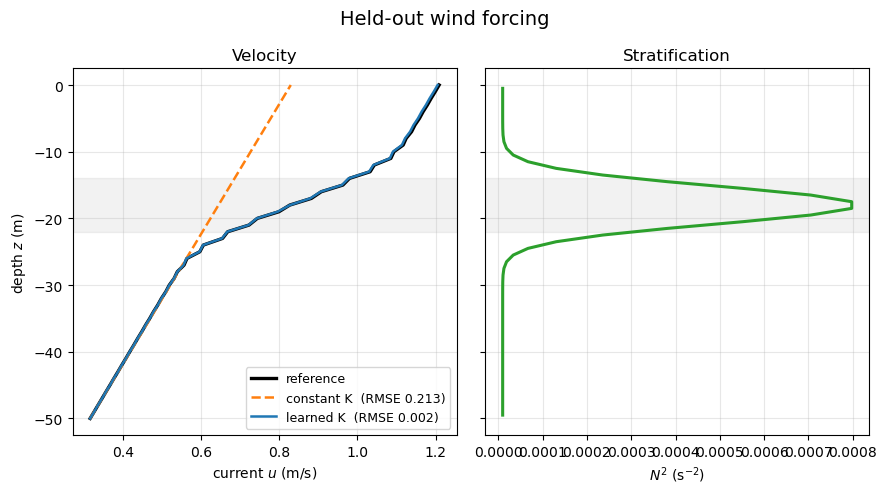

In [13]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(9, 5.0),
    sharey=True
)

# Highlight the strongly stratified layer
for ax in axes:
    ax.axhspan(-22, -14, color="grey", alpha=0.10)
    ax.grid(alpha=0.3)


# --------------------------------------------------
# 1. Velocity profile
# --------------------------------------------------
ax = axes[0]

ax.plot(
    u_ref, z_node,
    "k", lw=2.4,
    label="reference"
)

ax.plot(
    u_baseline, z_node,
    "C1", ls="--", lw=1.8,
    label=f"constant K  (RMSE {rmse_baseline:.3f})"
)

ax.plot(
    u_learned, z_node,
    "C0", lw=1.8,
    label=f"learned K  (RMSE {rmse_learned:.3f})"
)

ax.set_xlabel("current $u$ (m/s)")
ax.set_ylabel("depth $z$ (m)")
ax.set_title("Velocity")
ax.legend(fontsize=9)





# --------------------------------------------------
# 3. Prescribed stratification
# --------------------------------------------------
ax = axes[1]

ax.plot(
    N2_face, z_face,
    "C2", lw=2.2
)

ax.set_xlabel(r"$N^2$ (s$^{-2}$)")
ax.set_title("Stratification")


fig.suptitle(
    "Held-out wind forcing",
    fontsize=14
)

fig.tight_layout()
plt.show()

## 6. Held-out forcing cases

I evaluate the same learned closure under several wind forcings that were not used to
generate the training data. The strongest case is above the training forcing range.


In [8]:
print(f"{'wind tau_s/rho':>16}{'constant-K RMSE':>20}{'learned-K RMSE':>20}{'note':>24}")
print("-" * 80)

for tw in [1.5e-4, 3.5e-4, 5.0e-4, 8.0e-4]:
    ut, _, _ = solve_column(K_true_law, tw)
    uc, _, _ = solve_column(lambda S: np.full_like(S, K_const_val), tw)
    um, _, _ = solve_column(K_ml, tw)

    rc = np.sqrt(np.mean((uc - ut) ** 2))
    rm = np.sqrt(np.mean((um - ut) ** 2))
    note = "above training range" if tw > winds_train.max() else ""

    print(f"{tw:>16.1e}{rc:>20.4f}{rm:>20.4f}{note:>24}")


  wind tau_s/rho     constant-K RMSE      learned-K RMSE                    note
--------------------------------------------------------------------------------
         1.5e-04              0.2735              0.0038                        
         3.5e-04              0.1957              0.0007                        
         5.0e-04              0.1680              0.0024                        
         8.0e-04              0.1719              0.0037    above training range


         3.5e-04              0.1957              0.0010                        


         5.0e-04              0.1680              0.0033                        


         8.0e-04              0.1718              0.0142    above training range
